In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [6]:
df.duplicated().sum()

np.int64(418)

In [7]:
df.drop_duplicates(keep = "last", inplace=True)

In [8]:
df.shape

(49582, 2)

In [10]:
labels = {"negative" : 0, "positive" : 1}

# Feature Target
X = df.review
y = df.sentiment

target = y.replace(labels).to_numpy()

## Text Processing

In [15]:
import re
import nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [16]:
lemmatizer = nltk.stem.WordNetLemmatizer()

In [25]:
def text_processor(text: str) -> str:
    text = text.lower()

    # HTML Tags, URLs, Puncuation and Special Chars
    text = re.sub(r"<.+?>", "", text) # HTML TAGS
    text = re.sub(r"[(http(s)?):\/\/(www\.)?a-zA-Z0-9@:%._\+~#=]{2,256}\.[a-z]{2,6}\b([-a-zA-Z0-9@:%_\+.~#?&//=]*)", "", text) # URLS
    text = re.sub(r"[^\w\d\s]", " ", text) # Puncuation or special Chars
    text = text.strip()
    
    # Stopwords
    text = [word for word in text.split() if word not in ENGLISH_STOP_WORDS]
    text = [word for word in text if len(word) > 2]
    text = " ".join(text)

    # Lemmatization
    text = lemmatizer.lemmatize(text)

    return text
    

In [29]:
feature = X.apply(text_processor).to_numpy()

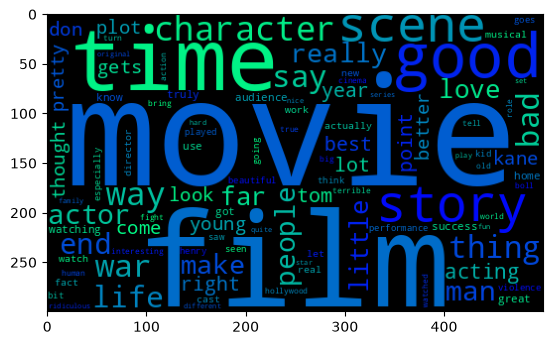

In [37]:
# Visualization

# !pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

cloud = WordCloud(
    colormap = "winter", max_words=100, width=500, height=300
)
image = cloud.generate(" ".join(feature[:50]))

plt.imshow(image)

## Vectorize or Embeddings

In [ ]:
# TFIDF Vectorizer
# WOR2Vec -> Train or pretrained
# BERT -> Pretrained